# SAMPIC external-trigger stream diagnostics

This notebook reads the structured output from `self_trigger_correlation_probe.sh`. It separates physical timestamp association from vendor-packet arrival order and capture-boundary effects.

> **Capture-condition note:** this newly collected stream is approximately 30 kHz. It contains 102,288 raw hits, but it retained the earlier `-562 ns` association offset; the new residual population is centered about 335 ns away from that configured offset. Consequently, configured-window accepted/populated counts are zero even though raw waveform data are present.

<style>
@media print {
  @page { size: A4 landscape; margin: 10mm; }
  .jp-Cell { break-inside: avoid; }
  .jp-OutputArea-output { overflow: visible !important; }
  .dataframe { font-size: 7pt !important; }
  img, svg { max-height: 170mm !important; object-fit: contain; }
}
</style>

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
# Matplotlib normally uses Unicode U+2212 for negative tick labels. Some
# notebook fonts render that character incorrectly, so force ASCII '-'.
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)

# Set SAMPIC_PROBE_RUN_DIR for non-interactive report generation, or set
# RUN_DIR_OVERRIDE here when comparing a saved run interactively.
_run_dir_from_environment = os.environ.get("SAMPIC_PROBE_RUN_DIR")
RUN_DIR_OVERRIDE = Path(_run_dir_from_environment).expanduser() if _run_dir_from_environment else None

_export_roots = [
    Path("../data/external_trigger_probe"),
    Path("scripts/tools/sampic_tests/data/external_trigger_probe"),
]
_export_root = next((path.resolve() for path in _export_roots if path.exists()), None)

if RUN_DIR_OVERRIDE is not None:
    RUN_DIR = RUN_DIR_OVERRIDE.resolve()
elif _export_root is None:
    raise FileNotFoundError("Could not find the external_trigger_probe data directory")
elif (_export_root / "latest" / "metadata.json").is_file():
    RUN_DIR = _export_root / "latest"
else:
    _valid_runs = [path for path in _export_root.iterdir() if (path / "metadata.json").is_file()]
    if not _valid_runs:
        raise FileNotFoundError(f"No diagnostic exports containing metadata.json below {_export_root}")
    RUN_DIR = max(_valid_runs, key=lambda path: (path / "metadata.json").stat().st_mtime)

print(f"Reading: {RUN_DIR}")

Reading: /home/pioneer/jcarlton/projects/midas_sampic/experiments/sampic_daq/scripts/tools/sampic_tests/data/external_trigger_probe/10khz_drained


In [2]:
with (RUN_DIR / "metadata.json").open() as stream:
    metadata = json.load(stream)

hits = pd.read_csv(RUN_DIR / "hits.csv")
triggers = pd.read_csv(RUN_DIR / "triggers.csv")
packets = pd.read_csv(RUN_DIR / "packets.csv")
hits["accepted"] = hits["accepted"].astype(bool)
hits["in_coverage_residual_ns"] = hits["residual_ns"].where(hits["coverage"] == "inside")

origin_ns = min(triggers["timestamp_ns"].min(), hits["target_trigger_timestamp_ns"].min())
triggers["time_ms"] = (triggers["timestamp_ns"] - origin_ns) / 1e6
hits["target_time_ms"] = (hits["target_trigger_timestamp_ns"] - origin_ns) / 1e6
hits["hit_time_ms"] = (hits["timestamp_ns"] - origin_ns) / 1e6

display(pd.DataFrame({
    "value": {
        "vendor packets": metadata["acquisition"]["decoded_vendor_events"],
        "hit records": len(hits),
        "trigger records": len(triggers),
        "accepted hits": int(hits["accepted"].sum()),
        "populated triggers": int((triggers["assigned_hits"] > 0).sum()),
        "configured offset (ns)": metadata["association"]["hit_time_offset_ns"],
        "pre/post window (ns)": f'{metadata["association"]["pre_window_ns"]} / {metadata["association"]["post_window_ns"]}',
    }
}))

,value
vendor packets,1265
hit records,8234
trigger records,12097
accepted hits,8225
populated triggers,1175
configured offset (ns),-562.0
pre/post window (ns),20.0 / 20.0


## Timestamp coverage

A hit target is its hit timestamp shifted by the configured offset. Hits marked `after` or `before` have no corresponding trigger timestamp in the captured trigger range, so their large nearest-trigger residuals are capture-boundary artifacts.

,coverage,accepted,hits
0,before,True,7
1,inside,False,9
2,inside,True,8218


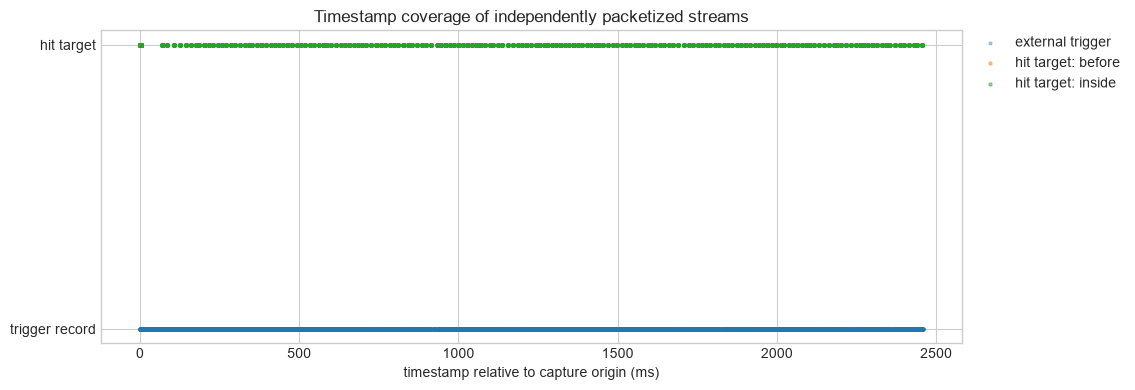

In [3]:
coverage_table = (
    hits.groupby(["coverage", "accepted"], observed=True)
        .size()
        .rename("hits")
        .reset_index()
)
display(coverage_table)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(triggers["time_ms"], np.zeros(len(triggers)), s=4, alpha=0.35, label="external trigger")
for coverage, group in hits.groupby("coverage", observed=True):
    ax.scatter(group["target_time_ms"], np.ones(len(group)), s=5, alpha=0.45, label=f"hit target: {coverage}")
ax.set_yticks([0, 1], ["trigger record", "hit target"])
ax.set_xlabel("timestamp relative to capture origin (ms)")
ax.set_title("Timestamp coverage of independently packetized streams")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

## Trigger timing and occupancy

,trigger interval (us)
count,12096.000000
mean,203.274748
std,435.238469
min,100.020000
1%,100.020000
50%,100.030000
95%,1300.370000
99%,2400.700000
max,5401.990000
rate from mean (Hz),4919.450205


,value
recorded trigger records,12097.000000
counter transitions with missing records,788.000000
counter-inferred missing trigger records,12484.000000
counter-inferred generated triggers,24581.000000
recorded fraction,0.492128


,value
populated triggers,1175.0
empty triggers,10922.0
mean hits / populated trigger,7.0
longest empty-trigger run,666.0


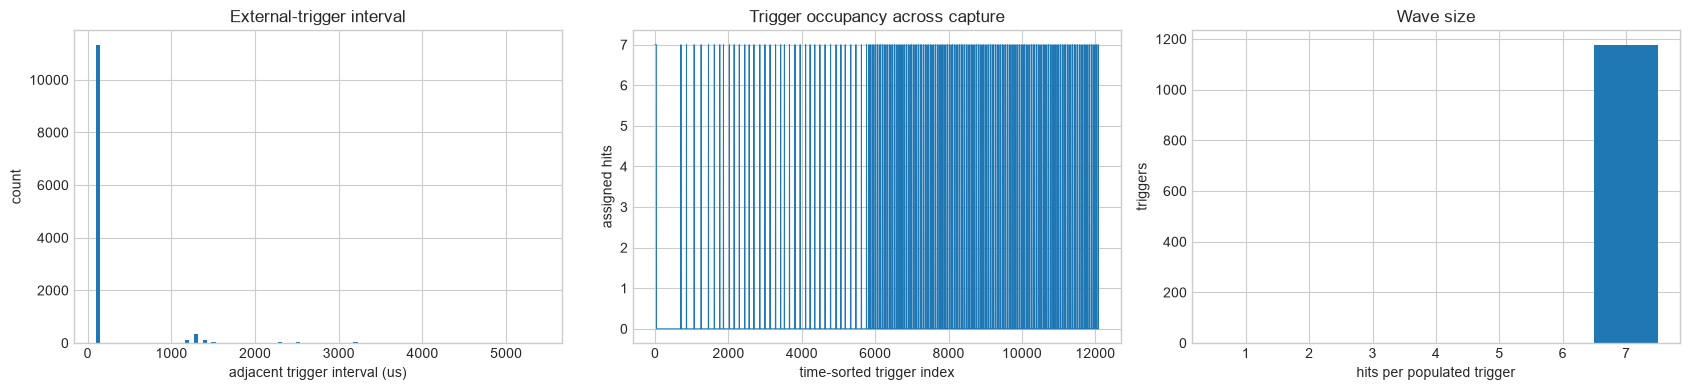

In [4]:
trigger_intervals_us = triggers["timestamp_ns"].diff().dropna() / 1e3
interval_summary = trigger_intervals_us.describe(percentiles=[0.01, 0.5, 0.95, 0.99]).to_frame("trigger interval (us)")
display(interval_summary)
excitation_wall_s = float(metadata["acquisition"].get("excitation_wall_s") or metadata["acquisition"]["requested_duration_s"])
requested_rate_hz = metadata["acquisition"].get("lecroy_readback_rate_hz") or metadata["acquisition"].get("lecroy_requested_rate_hz")
rate_summary = pd.DataFrame({"value": {
    "generator requested/read-back rate (Hz)": requested_rate_hz,
    "received trigger records / excitation wall time (Hz)": len(triggers) / excitation_wall_s,
    "timestamp-implied trigger rate (Hz)": 1e6 / trigger_intervals_us.mean(),
}})
display(rate_summary)

# TriggerIDFromFPGA is stored as an 8-bit value in this configuration. Modulo
# 256 increments still expose missing records as long as one gap is <256.
fpga_id_increment = triggers["fpga_id"].astype(int).diff().dropna().astype(int) % 256
missing_trigger_records = ((fpga_id_increment - 1) % 256).sum()
inferred_trigger_records = len(triggers) + int(missing_trigger_records)
trigger_counter_summary = pd.DataFrame({
    "value": {
        "recorded trigger records": len(triggers),
        "counter transitions with missing records": int((fpga_id_increment != 1).sum()),
        "counter-inferred missing trigger records": int(missing_trigger_records),
        "counter-inferred generated triggers": inferred_trigger_records,
        "recorded fraction": len(triggers) / inferred_trigger_records,
    }
})
display(trigger_counter_summary)

populated = triggers["assigned_hits"] > 0
empty = ~populated
empty_group = populated.cumsum()
empty_runs = triggers.loc[empty].groupby(empty_group[empty]).size().sort_values(ascending=False)

occupancy_summary = pd.DataFrame({
    "value": {
        "populated triggers": int(populated.sum()),
        "empty triggers": int(empty.sum()),
        "mean hits / populated trigger": triggers.loc[populated, "assigned_hits"].mean(),
        "longest empty-trigger run": int(empty_runs.iloc[0]) if len(empty_runs) else 0,
    }
})
display(occupancy_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(trigger_intervals_us, bins=100)
axes[0].set_xlabel("adjacent trigger interval (us)")
axes[0].set_ylabel("count")
axes[0].set_title("External-trigger interval")

axes[1].plot(triggers["sorted_trigger_index"], triggers["assigned_hits"], linewidth=0.7)
axes[1].set_xlabel("time-sorted trigger index")
axes[1].set_ylabel("assigned hits")
axes[1].set_title("Trigger occupancy across capture")

populated_wave_sizes = triggers.loc[populated, "assigned_hits"]
axes[2].hist(populated_wave_sizes, bins=np.arange(0.5, populated_wave_sizes.max() + 1.5, 1))
axes[2].set_yscale("log")
axes[2].set_xticks(np.arange(1, populated_wave_sizes.max() + 1))
axes[2].set_xlabel("hits per populated trigger")
axes[2].set_ylabel("triggers (log scale)")
axes[2].set_title("Wave size, including rare outliers")
plt.tight_layout()
plt.show()

### Empty and populated triggers in time order

The upper panel shows every external-trigger record at its timestamp. A populated trigger has at least one assigned hit; an empty trigger has none. The lower panel summarizes local occupancy without hiding the individual trigger positions.

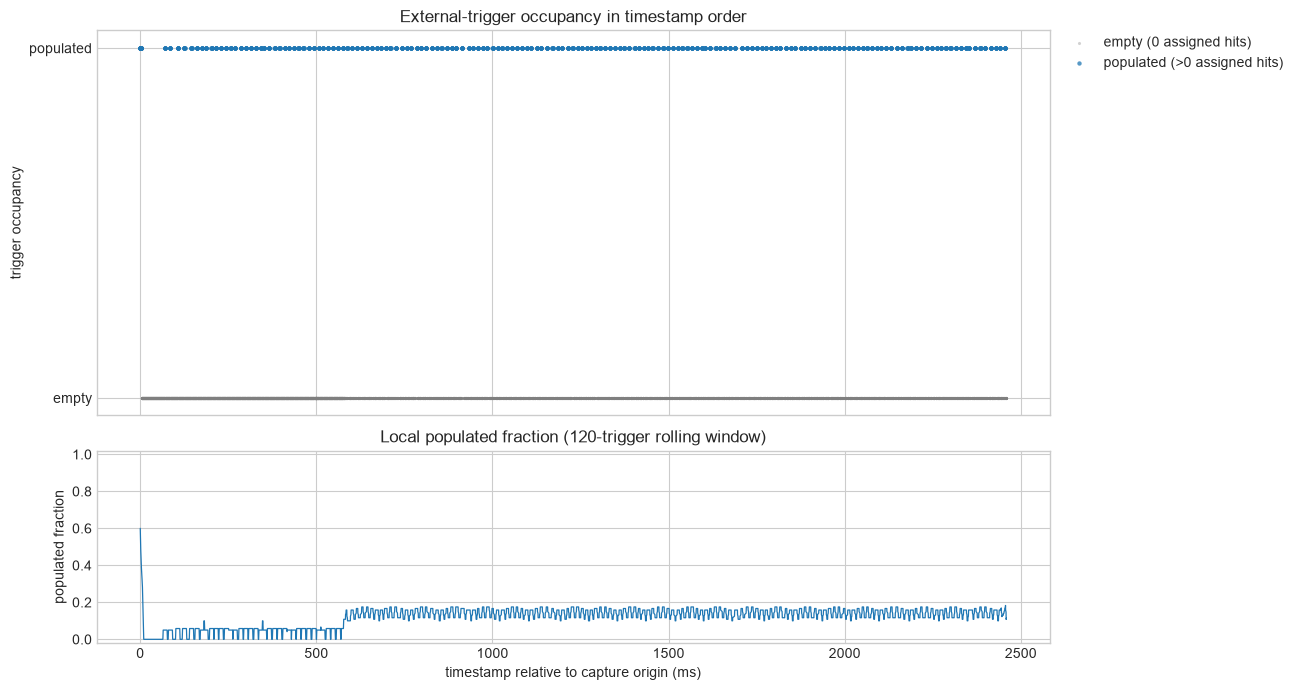

In [5]:
occupancy_window = max(10, min(200, len(triggers) // 100))
local_populated_fraction = populated.astype(float).rolling(
    occupancy_window, center=True, min_periods=1
).mean()

fig, axes = plt.subplots(
    2, 1, figsize=(16, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].scatter(
    triggers.loc[empty, "time_ms"],
    np.zeros(int(empty.sum())),
    s=5, alpha=0.35, color="tab:gray", linewidths=0,
    label="empty (0 assigned hits)",
)
axes[0].scatter(
    triggers.loc[populated, "time_ms"],
    np.ones(int(populated.sum())),
    s=10, alpha=0.75, color="tab:blue", linewidths=0,
    label="populated (>0 assigned hits)",
)
axes[0].set_yticks([0, 1], ["empty", "populated"])
axes[0].set_ylabel("trigger occupancy")
axes[0].set_title("External-trigger occupancy in timestamp order")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

axes[1].plot(
    triggers["time_ms"], local_populated_fraction,
    color="tab:blue", linewidth=0.9,
)
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlabel("timestamp relative to capture origin (ms)")
axes[1].set_ylabel("populated fraction")
axes[1].set_title(f"Local populated fraction ({occupancy_window}-trigger rolling window)")

fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

### Zoomed hit-to-trigger pattern

This view uses the first 98 hit records in timestamp order to choose a trigger interval, then expands the displayed hit set to include every hit assigned to the boundary triggers. Consequently, every trigger labeled populated has its matched hit targets drawn; empty intervening triggers remain visible.

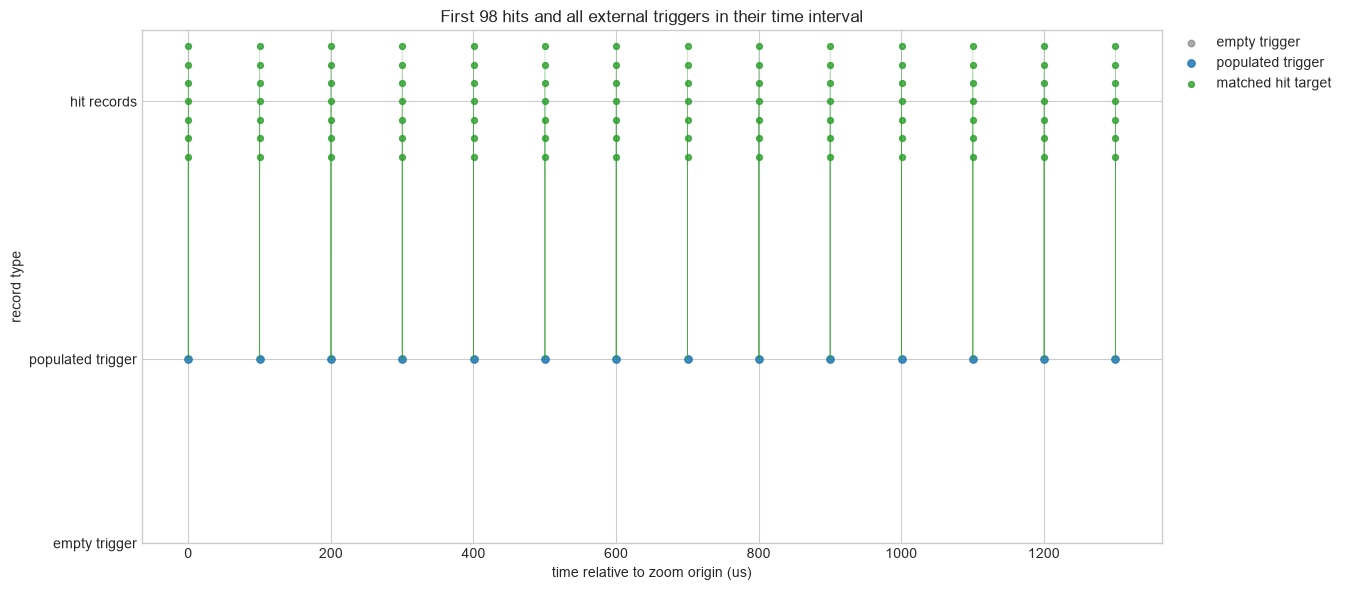

In [6]:
zoom_hit_count = 98
zoom_seed_hits = (
    hits.sort_values(["target_trigger_timestamp_ns", "event_index", "hit_index"])
        .head(zoom_hit_count)
        .copy()
)
if zoom_seed_hits.empty:
    raise ValueError("No hits are available for the zoomed timeline")

first_trigger_index = int(zoom_seed_hits["nearest_trigger_sorted_index"].min())
last_trigger_index = int(zoom_seed_hits["nearest_trigger_sorted_index"].max())
zoom_triggers = triggers[
    triggers["sorted_trigger_index"].between(first_trigger_index, last_trigger_index)
].copy()
zoom_hits = hits[
    hits["nearest_trigger_sorted_index"].between(first_trigger_index, last_trigger_index)
].copy()
zoom_origin_ns = min(
    zoom_hits["target_trigger_timestamp_ns"].min(),
    zoom_triggers["timestamp_ns"].min(),
)
zoom_hits["target_time_us"] = (
    zoom_hits["target_trigger_timestamp_ns"] - zoom_origin_ns
) / 1e3
zoom_hits["nearest_trigger_time_us"] = (
    zoom_hits["nearest_trigger_timestamp_ns"] - zoom_origin_ns
) / 1e3
zoom_triggers["zoom_time_us"] = (
    zoom_triggers["timestamp_ns"] - zoom_origin_ns
) / 1e3

# Spread hits belonging to the same trigger vertically so individual records
# remain visible instead of lying directly on top of one another.
hit_position = zoom_hits.groupby("nearest_trigger_sorted_index").cumcount()
hit_multiplicity = zoom_hits.groupby("nearest_trigger_sorted_index")["hit_index"].transform("size")
zoom_hits["plot_y"] = 2.0 + 0.8 * (hit_position + 1) / (hit_multiplicity + 1)

zoom_trigger_populated = zoom_triggers["assigned_hits"] > 0
fig, ax = plt.subplots(figsize=(17, 6))
ax.scatter(
    zoom_triggers.loc[~zoom_trigger_populated, "zoom_time_us"],
    np.zeros(int((~zoom_trigger_populated).sum())),
    s=22, color="tab:gray", alpha=0.65,
    label="empty trigger",
)
ax.scatter(
    zoom_triggers.loc[zoom_trigger_populated, "zoom_time_us"],
    np.ones(int(zoom_trigger_populated.sum())),
    s=28, color="tab:blue", alpha=0.85,
    label="populated trigger",
)

for row in zoom_hits.itertuples(index=False):
    ax.plot(
        [row.nearest_trigger_time_us, row.target_time_us],
        [1.0, row.plot_y],
        color="tab:green" if row.accepted else "tab:orange",
        alpha=0.3, linewidth=0.6,
    )

accepted_zoom_hits = zoom_hits[zoom_hits["accepted"]]
rejected_zoom_hits = zoom_hits[~zoom_hits["accepted"]]
ax.scatter(
    accepted_zoom_hits["target_time_us"], accepted_zoom_hits["plot_y"],
    s=18, color="tab:green", alpha=0.8, label="matched hit target",
)
if not rejected_zoom_hits.empty:
    ax.scatter(
        rejected_zoom_hits["target_time_us"], rejected_zoom_hits["plot_y"],
        s=28, marker="x", color="tab:orange", label="unmatched hit target",
    )

ax.set_yticks([0, 1, 2.4], ["empty trigger", "populated trigger", "hit records"])
ax.set_xlabel("time relative to zoom origin (us)")
ax.set_ylabel("record type")
ax.set_title(
    f"First {zoom_hit_count} hits, expanded to {len(zoom_hits)} to complete boundary trigger waves"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.tight_layout(rect=(0, 0, 0.80, 1))
plt.show()

### Longest empty-trigger runs

This diagnostic finds contiguous runs of empty triggers that have populated triggers both before and after them. It plots the two longest such runs with three populated triggers of context on each side. If the configured association accepts no hits, the full all-empty capture is shown instead.

,start_position,end_position,empty_triggers,duration_us
0,36,701,666,66522.00
1,858,1060,203,20206.64


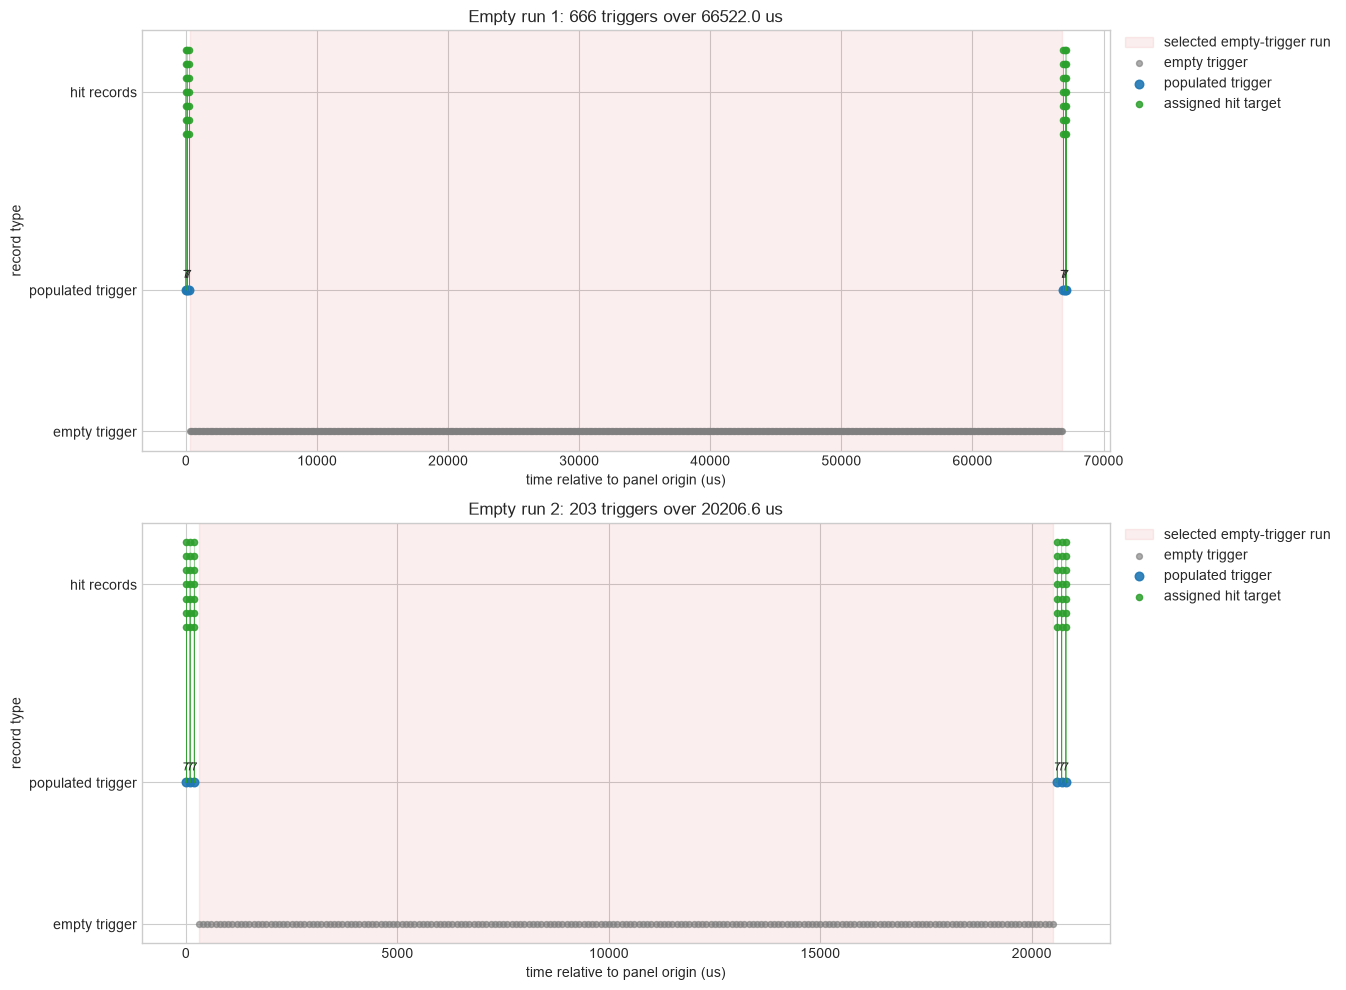

In [7]:
context_populated_triggers = 3
populated_positions = np.flatnonzero(populated.to_numpy())
empty_positions = np.flatnonzero(empty.to_numpy())

bounded_empty_runs = []
if len(empty_positions):
    run_boundaries = np.flatnonzero(np.diff(empty_positions) > 1) + 1
    for run in np.split(empty_positions, run_boundaries):
        if len(run) == 0:
            continue
        start_position = int(run[0])
        end_position = int(run[-1])
        has_populated_before = np.any(populated_positions < start_position)
        has_populated_after = np.any(populated_positions > end_position)
        if has_populated_before and has_populated_after:
            bounded_empty_runs.append({
                "start_position": start_position,
                "end_position": end_position,
                "empty_triggers": len(run),
                "duration_us": (
                    triggers.iloc[end_position]["timestamp_ns"]
                    - triggers.iloc[start_position]["timestamp_ns"]
                ) / 1e3,
            })

selected_empty_runs = sorted(
    bounded_empty_runs,
    key=lambda run: (run["empty_triggers"], run["duration_us"]),
    reverse=True,
)[:2]
if not selected_empty_runs and len(triggers) and empty.all():
    selected_empty_runs = [{
        "start_position": 0,
        "end_position": len(triggers) - 1,
        "empty_triggers": len(triggers),
        "duration_us": (triggers.iloc[-1]["timestamp_ns"] - triggers.iloc[0]["timestamp_ns"]) / 1e3,
    }]
elif not selected_empty_runs:
    raise ValueError("No empty-trigger run was available to plot")

display(pd.DataFrame(selected_empty_runs))

fig, axes = plt.subplots(
    len(selected_empty_runs), 1,
    figsize=(17, 5 * len(selected_empty_runs)),
    squeeze=False,
)

for plot_index, run in enumerate(selected_empty_runs):
    ax = axes[plot_index, 0]
    start_position = run["start_position"]
    end_position = run["end_position"]

    populated_before = populated_positions[populated_positions < start_position]
    populated_after = populated_positions[populated_positions > end_position]
    context_before = populated_before[-context_populated_triggers:]
    context_after = populated_after[:context_populated_triggers]
    view_start = int(context_before[0]) if len(context_before) else start_position
    view_end = int(context_after[-1]) if len(context_after) else end_position

    trigger_view = triggers.iloc[view_start:view_end + 1].copy()
    view_origin_ns = trigger_view["timestamp_ns"].min()
    trigger_view["view_time_us"] = (
        trigger_view["timestamp_ns"] - view_origin_ns
    ) / 1e3
    view_populated = trigger_view["assigned_hits"] > 0

    trigger_ids = set(trigger_view["sorted_trigger_index"])
    hit_view = hits[
        hits["accepted"]
        & hits["nearest_trigger_sorted_index"].isin(trigger_ids)
    ].copy()
    hit_view["view_time_us"] = (
        hit_view["target_trigger_timestamp_ns"] - view_origin_ns
    ) / 1e3
    hit_position = hit_view.groupby("nearest_trigger_sorted_index").cumcount()
    hit_multiplicity = hit_view.groupby("nearest_trigger_sorted_index")["hit_index"].transform("size")
    hit_view["plot_y"] = 2.0 + 0.8 * (hit_position + 1) / (hit_multiplicity + 1)

    empty_run_start_us = (
        triggers.iloc[start_position]["timestamp_ns"] - view_origin_ns
    ) / 1e3
    empty_run_end_us = (
        triggers.iloc[end_position]["timestamp_ns"] - view_origin_ns
    ) / 1e3
    ax.axvspan(
        empty_run_start_us, empty_run_end_us,
        color="tab:red", alpha=0.08,
        label="selected empty-trigger run",
    )
    ax.scatter(
        trigger_view.loc[~view_populated, "view_time_us"],
        np.zeros(int((~view_populated).sum())),
        s=18, color="tab:gray", alpha=0.65,
        label="empty trigger",
    )
    ax.scatter(
        trigger_view.loc[view_populated, "view_time_us"],
        np.ones(int(view_populated.sum())),
        s=38, color="tab:blue", alpha=0.9,
        label="populated trigger",
    )

    trigger_time_by_index = trigger_view.set_index("sorted_trigger_index")["view_time_us"]
    for row in hit_view.itertuples(index=False):
        trigger_time_us = trigger_time_by_index.loc[row.nearest_trigger_sorted_index]
        ax.plot(
            [trigger_time_us, row.view_time_us],
            [1.0, row.plot_y],
            color="tab:green", alpha=0.35, linewidth=0.7,
        )
    ax.scatter(
        hit_view["view_time_us"], hit_view["plot_y"],
        s=20, color="tab:green", alpha=0.85,
        label="assigned hit target",
    )

    for row in trigger_view.loc[view_populated].itertuples(index=False):
        ax.annotate(
            str(int(row.assigned_hits)),
            (row.view_time_us, 1.0),
            xytext=(0, 7), textcoords="offset points",
            ha="center", va="bottom", fontsize=8,
        )

    ax.set_yticks([0, 1, 2.4], ["empty trigger", "populated trigger", "hit records"])
    ax.set_xlabel("time relative to panel origin (us)")
    ax.set_ylabel("record type")
    ax.set_title(
        f'Empty run {plot_index + 1}: {run["empty_triggers"]} triggers '
        f'over {run["duration_us"]:.1f} us'
    )
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

fig.tight_layout(rect=(0, 0, 0.80, 1))
plt.show()

## Association residuals

The primary residual plot deliberately includes only hit targets inside captured trigger coverage. This avoids allowing missing tail records to dominate the scale.

,residual_ns
count,8227.000000
mean,-0.157264
std,4.490200
min,-10.343750
0.1%,-9.718750
1%,-7.490625
50%,-0.343750
99%,9.459375
99.9%,53.738437
max,69.343750


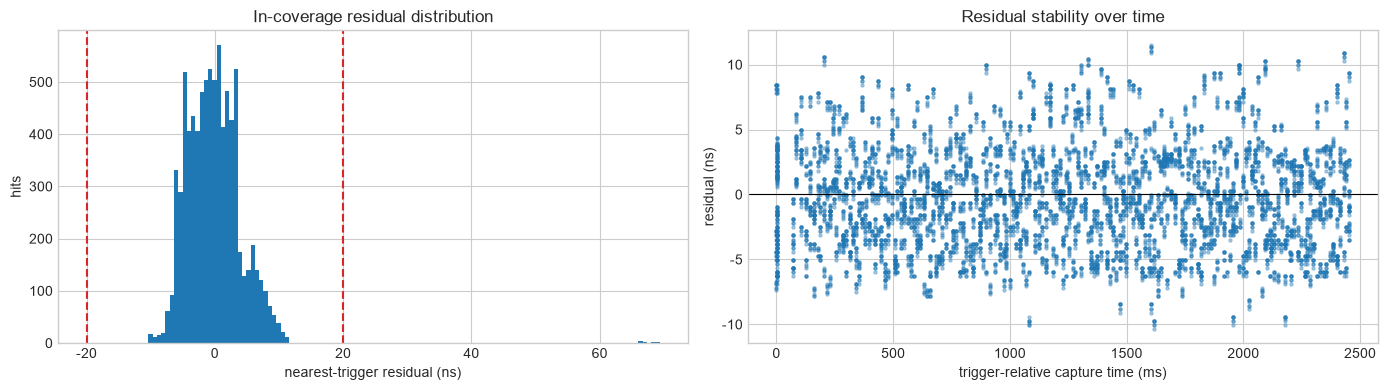

In [8]:
inside = hits[hits["coverage"] == "inside"].copy()
display(inside["residual_ns"].describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(inside["residual_ns"], bins=120)
axes[0].axvline(-metadata["association"]["pre_window_ns"], color="tab:red", linestyle="--")
axes[0].axvline(metadata["association"]["post_window_ns"], color="tab:red", linestyle="--")
axes[0].set_xlabel("nearest-trigger residual (ns)")
axes[0].set_ylabel("hits")
axes[0].set_title("In-coverage residual distribution")

accepted = inside[inside["accepted"]]
axes[1].scatter(accepted["target_time_ms"], accepted["residual_ns"], s=5, alpha=0.35)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("trigger-relative capture time (ms)")
axes[1].set_ylabel("residual (ns)")
axes[1].set_title("Residual stability over time")
plt.tight_layout()
plt.show()

## Vendor packetization

Packet lag is `hit vendor event - matched trigger vendor event`: negative values mean the hit packet arrived first, zero means both records shared a vendor event, and positive values mean the trigger packet arrived first. For each hit-bearing vendor packet, the ticker groups all accepted hits originating in that packet. Its median line is the typical lag among those hits, while the min-max band spans the earliest and latest matched-trigger packet used by any hit in the group. Because packet occupancy varies, the band describes association spread rather than packet size; packet size is shown separately above. The ticker uses a symmetric-log vertical scale to keep the common near-zero lags and rare large excursions visible together; tick labels remain in vendor-event units.

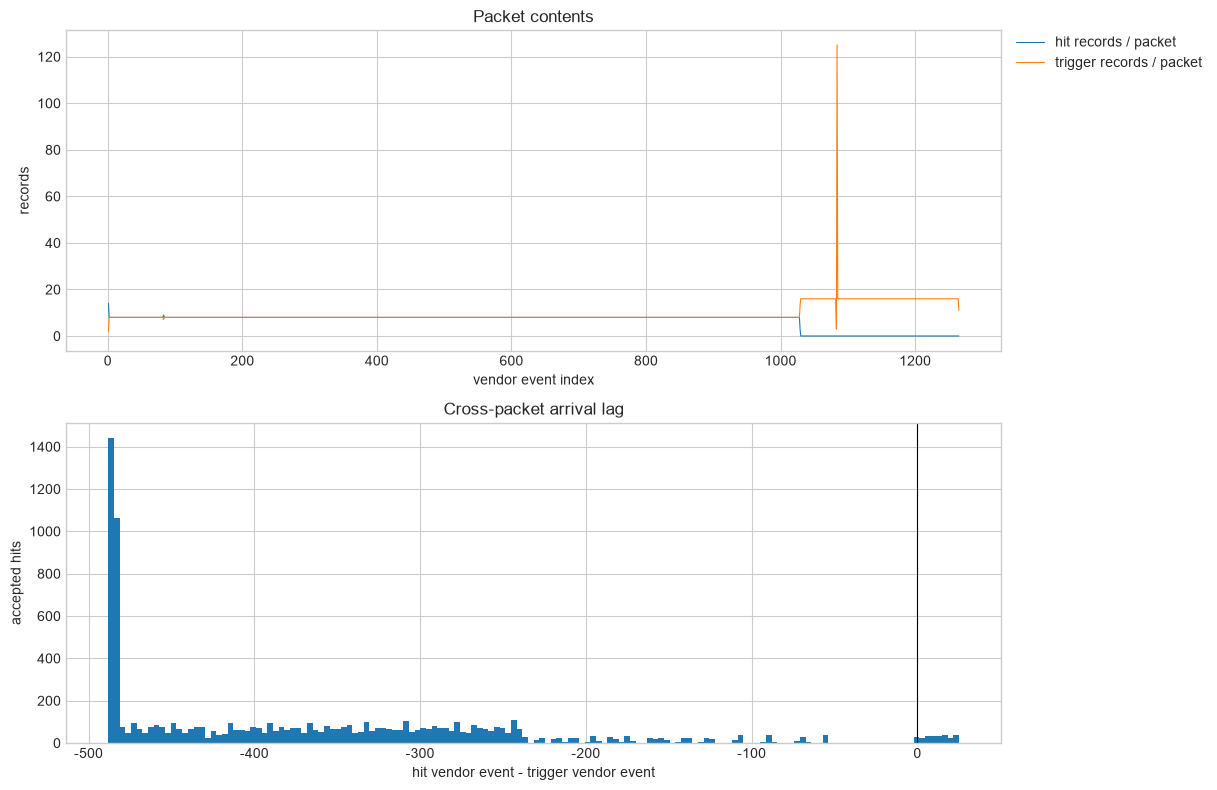

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(17, 9), sharex=False)
axes[0, 0].plot(packets["event_index"], packets["hit_count"], label="hit records / packet", linewidth=0.8)
axes[0, 0].plot(packets["event_index"], packets["trigger_count"], label="trigger records / packet", linewidth=0.8)
axes[0, 0].set_xlabel("vendor event index")
axes[0, 0].set_ylabel("records")
axes[0, 0].set_title("Packet contents in arrival order")
axes[0, 0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

packet_bin_edges = np.linspace(0, max(packets["hit_count"].max(), packets["trigger_count"].max()), 50)
axes[0, 1].hist(packets["hit_count"], bins=packet_bin_edges, histtype="step", linewidth=1.4, label="hit records")
axes[0, 1].hist(packets["trigger_count"], bins=packet_bin_edges, histtype="step", linewidth=1.4, label="trigger records")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("records in one vendor event")
axes[0, 1].set_ylabel("vendor events (log scale)")
axes[0, 1].set_title("Packet-content histogram")
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

accepted_hits = hits[hits["accepted"]].copy()
lag_values = accepted_hits["packet_lag"].astype(int)
central_lags = np.arange(-5, 6)
lag_counts = [int((lag_values < -5).sum())]
lag_counts.extend(int((lag_values == lag).sum()) for lag in central_lags)
lag_counts.append(int((lag_values > 5).sum()))
lag_labels = ["<-5", *[f"{lag:+d}" for lag in central_lags], ">+5"]
axes[1, 0].bar(np.arange(len(lag_counts)), lag_counts)
axes[1, 0].set_yscale("log")
axes[1, 0].set_xticks(np.arange(len(lag_labels)), labels=lag_labels, rotation=45)
axes[1, 0].set_xlabel("hit packet index - matched-trigger packet index")
axes[1, 0].set_ylabel("accepted hits (log scale)")
axes[1, 0].set_title("Rebinned cross-packet arrival lag")

lag_by_packet = accepted_hits.groupby("event_index")["packet_lag"].agg(["min", "median", "max"]).reset_index()
axes[1, 1].fill_between(lag_by_packet["event_index"], lag_by_packet["min"], lag_by_packet["max"], color="#3b82c4", alpha=0.5, label="all-hit min-max range")
axes[1, 1].plot(lag_by_packet["event_index"], lag_by_packet["min"], color="#1f5f99", linewidth=0.7, alpha=0.9)
axes[1, 1].plot(lag_by_packet["event_index"], lag_by_packet["max"], color="#1f5f99", linewidth=0.7, alpha=0.9)
axes[1, 1].plot(lag_by_packet["event_index"], lag_by_packet["median"], color="#d95f02", linewidth=1.1, label="median hit lag")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_yscale("symlog", linthresh=5)
lag_ticks = np.array([-100, -10, -1, 0, 1, 10, 100])
axes[1, 1].set_yticks(lag_ticks, labels=[str(value) for value in lag_ticks])
axes[1, 1].set_xlabel("hit vendor event index")
axes[1, 1].set_ylabel("hit packet - matched-trigger packet")
axes[1, 1].set_title("Cross-packet lag in arrival order (symmetric-log scale)")
axes[1, 1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()

In [ ]:
expected_channel_hits = hits[
    (hits["feb"] == 1)
    & (hits["sampic"] == 1)
    & hits["channel"].between(25, 31)
].copy()
expected_hit_count_by_packet = (
    expected_channel_hits.groupby("event_index").size()
    .reindex(packets["event_index"], fill_value=0)
)
expected_accepted_hits = expected_channel_hits[expected_channel_hits["accepted"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(17, 9), sharex=False)
fig.suptitle("Vendor packetization: FEB 1 / SAMPIC 1 / channels 25-31 only", fontsize=15)
axes[0, 0].plot(packets["event_index"], expected_hit_count_by_packet.to_numpy(), label="selected hit records / packet", linewidth=0.8)
axes[0, 0].plot(packets["event_index"], packets["trigger_count"], label="trigger records / packet", linewidth=0.8)
axes[0, 0].set_xlabel("vendor event index")
axes[0, 0].set_ylabel("records")
axes[0, 0].set_title("Packet contents in arrival order")
axes[0, 0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

axes[0, 1].hist(expected_hit_count_by_packet, bins=packet_bin_edges, histtype="step", linewidth=1.4, label="selected hit records")
axes[0, 1].hist(packets["trigger_count"], bins=packet_bin_edges, histtype="step", linewidth=1.4, label="trigger records")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("records in one vendor event")
axes[0, 1].set_ylabel("vendor events (log scale)")
axes[0, 1].set_title("Packet-content histogram")
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

expected_lag_values = expected_accepted_hits["packet_lag"].astype(int)
expected_lag_counts = [int((expected_lag_values < -5).sum())]
expected_lag_counts.extend(int((expected_lag_values == lag).sum()) for lag in central_lags)
expected_lag_counts.append(int((expected_lag_values > 5).sum()))
axes[1, 0].bar(np.arange(len(expected_lag_counts)), expected_lag_counts)
axes[1, 0].set_yscale("log")
axes[1, 0].set_xticks(np.arange(len(lag_labels)), labels=lag_labels, rotation=45)
axes[1, 0].set_xlabel("hit packet index - matched-trigger packet index")
axes[1, 0].set_ylabel("accepted selected-channel hits (log scale)")
axes[1, 0].set_title("Rebinned cross-packet arrival lag")

expected_lag_by_packet = expected_accepted_hits.groupby("event_index")["packet_lag"].agg(["min", "median", "max"]).reset_index()
axes[1, 1].fill_between(expected_lag_by_packet["event_index"], expected_lag_by_packet["min"], expected_lag_by_packet["max"], color="#3b82c4", alpha=0.5, label="selected-hit min-max range")
axes[1, 1].plot(expected_lag_by_packet["event_index"], expected_lag_by_packet["min"], color="#1f5f99", linewidth=0.7, alpha=0.9)
axes[1, 1].plot(expected_lag_by_packet["event_index"], expected_lag_by_packet["max"], color="#1f5f99", linewidth=0.7, alpha=0.9)
axes[1, 1].plot(expected_lag_by_packet["event_index"], expected_lag_by_packet["median"], color="#d95f02", linewidth=1.1, label="median selected-hit lag")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_yscale("symlog", linthresh=5)
axes[1, 1].set_yticks(lag_ticks, labels=[str(value) for value in lag_ticks])
axes[1, 1].set_xlabel("hit vendor event index")
axes[1, 1].set_ylabel("hit packet - matched-trigger packet")
axes[1, 1].set_title("Cross-packet lag in arrival order (symmetric-log scale)")
axes[1, 1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.tight_layout(rect=(0, 0, 0.84, 0.95))
plt.show()

## Hardware-address tables

In [10]:
channel_table = (
    hits.groupby(["feb", "sampic", "channel"], observed=True)
        .agg(
            records=("hit_index", "size"),
            accepted=("accepted", "sum"),
            residual_mean_ns=("in_coverage_residual_ns", "mean"),
            residual_std_ns=("in_coverage_residual_ns", "std"),
            packet_lag_median=("packet_lag", "median"),
        )
        .reset_index()
        .sort_values(["accepted", "records"], ascending=False)
)
display(channel_table.head(40))

feb_table = (
    hits.groupby("feb", observed=True)
        .agg(records=("hit_index", "size"), accepted=("accepted", "sum"), residual_mean_ns=("in_coverage_residual_ns", "mean"))
)
display(feb_table)

,feb,sampic,channel,records,accepted,residual_mean_ns,residual_std_ns,packet_lag_median
3,1,1,25,1175,1175,-0.196284,3.932571,-397.0
4,1,1,26,1175,1175,-0.180579,3.935781,-397.0
5,1,1,27,1175,1175,-0.274143,3.852332,-397.0
6,1,1,28,1175,1175,-0.168601,3.915302,-397.0
7,1,1,29,1175,1175,-0.272147,3.873940,-396.0
8,1,1,30,1175,1175,-0.157954,3.939899,-396.0
9,1,1,31,1175,1175,-0.368239,3.839390,-397.0
0,0,0,3,1,0,69.343750,NaN,-255.0
1,0,0,14,1,0,68.406250,NaN,-255.0
2,0,0,15,1,0,69.031250,NaN,-255.0


,records,accepted,residual_mean_ns
feb,,,
0,3,0,68.927083
1,8231,8225,-0.182465
